# KDD Cup 2010 Clustering — Final

This notebook applies the final corrected protocol to KDD Algebra 2005–2006: chronological early/future splitting, discovery/validation learners, missing-aware empirical-Bayes mastery, exposure ablations, cluster stability, genuine repeated learner subsamples, temporal external validation, and tests of clustering's incremental predictive value. A fallback K is explicitly marked exploratory when no candidate passes the acceptance gates.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Imports and configuration

In [2]:
from pathlib import Path
from itertools import combinations
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import kruskal
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    adjusted_rand_score, calinski_harabasz_score, davies_bouldin_score,
    mean_absolute_error, normalized_mutual_info_score, silhouette_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
DATA_PATH = '/content/drive/MyDrive/datasets/algebra_2005_2006_train.txt'
OUTPUT_DIR = Path('/content/drive/MyDrive/datasets/kdd_final_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ROW_LIMIT = None
MIN_INTERACTIONS = 20
EARLY_FRACTION = 0.70
MIN_SKILL_LEARNERS = 10
MASTERY_PRIOR_STRENGTH = 5.0
PCA_VARIANCE = 0.95
K_VALUES = list(range(2, 10))
INTERPRET_K_VALUES = [5, 6]
STABILITY_REPEATS = 10
STABILITY_SAMPLE_FRACTION = 0.80
SILHOUETTE_SAMPLE_SIZE = 5_000
ALGORITHM_SAMPLE_FRACTION = 0.80
ALGORITHM_REPEATS = 10
RUN_SUPERVISED_IMPORTANCE = True

## Load and audit the dataset

In [3]:
df = pd.read_csv(DATA_PATH, sep='\t', nrows=ROW_LIMIT, low_memory=False)
print('Loaded shape:', df.shape)
display(df.head())
display(df.dtypes)

Loaded shape: (809694, 19)


,Row,Anon Student Id,Problem Hierarchy,Problem Name,Problem View,Step Name,Step Start Time,First Transaction Time,Correct Transaction Time,Step End Time,Step Duration (sec),Correct Step Duration (sec),Error Step Duration (sec),Correct First Attempt,Incorrects,Hints,Corrects,KC(Default),Opportunity(Default)
0,1,0BrbPbwCMz,"Unit ES_04, Section ES_04-1",EG4-FIXED,1,3(x+2) = 15,2005-09-09 12:24:35.0,2005-09-09 12:24:49.0,2005-09-09 12:25:15.0,2005-09-09 12:25:15.0,40.0,NaN,40.0,0,2,3,1,[SkillRule: Eliminate Parens; {CLT nested; CLT...,1
1,2,0BrbPbwCMz,"Unit ES_04, Section ES_04-1",EG4-FIXED,1,x+2 = 5,2005-09-09 12:25:15.0,2005-09-09 12:25:31.0,2005-09-09 12:25:31.0,2005-09-09 12:25:31.0,16.0,16.0,NaN,1,0,0,1,"[SkillRule: Remove constant; {ax+b=c, positive...",1~~1
2,3,0BrbPbwCMz,"Unit ES_04, Section ES_04-1",EG40,1,2-8y = -4,2005-09-09 12:25:36.0,2005-09-09 12:25:43.0,2005-09-09 12:26:12.0,2005-09-09 12:26:12.0,36.0,NaN,36.0,0,2,3,1,"[SkillRule: Remove constant; {ax+b=c, positive...",2
3,4,0BrbPbwCMz,"Unit ES_04, Section ES_04-1",EG40,1,-8y = -6,2005-09-09 12:26:12.0,2005-09-09 12:26:34.0,2005-09-09 12:26:34.0,2005-09-09 12:26:34.0,22.0,22.0,NaN,1,0,0,1,"[SkillRule: Remove coefficient; {ax+b=c, divid...",1~~1
4,5,0BrbPbwCMz,"Unit ES_04, Section ES_04-1",EG40,2,-7y-5 = -4,2005-09-09 12:26:38.0,2005-09-09 12:28:36.0,2005-09-09 12:28:36.0,2005-09-09 12:28:36.0,118.0,118.0,NaN,1,0,0,1,"[SkillRule: Remove constant; {ax+b=c, positive...",3~~1


,0
Row,int64
Anon Student Id,object
Problem Hierarchy,object
Problem Name,object
Problem View,int64
Step Name,object
Step Start Time,object
First Transaction Time,object
Correct Transaction Time,object
Step End Time,object


## Cleaning and chronological event order

Negative durations are treated as missing. Rows with missing knowledge components remain available for behavioural summaries but do not become an artificial mastery skill.

In [4]:
numeric_cols = [
    'Row', 'Problem View', 'Step Duration (sec)',
    'Correct Step Duration (sec)', 'Error Step Duration (sec)',
    'Correct First Attempt', 'Incorrects', 'Hints', 'Corrects',
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

time_cols = ['Step Start Time', 'First Transaction Time', 'Step End Time']
for col in time_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')
df['event_time'] = (
    df['Step Start Time']
      .fillna(df['First Transaction Time'])
      .fillna(df['Step End Time'])
)

audit = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_count': df.isna().sum(),
    'missing_percent': 100 * df.isna().mean(),
    'unique_values': df.nunique(dropna=True),
}).sort_values('missing_percent', ascending=False)
display(audit)

valid_row_id = df['Row'].notna()
print('Duplicate non-missing Row values:', df.loc[valid_row_id].duplicated('Row').sum())
print('Invalid correctness rows:', (~df['Correct First Attempt'].isin([0, 1])).sum())
print('Missing event timestamps:', df['event_time'].isna().sum())
print('Negative durations:', (df['Step Duration (sec)'] < 0).sum())

duplicate_event = df['Row'].notna() & df.duplicated('Row', keep='first')
df = df.loc[~duplicate_event].copy()
df = df[df['Anon Student Id'].notna() & df['Correct First Attempt'].isin([0, 1])].copy()
df.loc[df['Step Duration (sec)'] < 0, 'Step Duration (sec)'] = np.nan
df['duration_log'] = np.log1p(df['Step Duration (sec)'])
df['KC_List'] = df['KC(Default)'].fillna('').astype(str).str.split('~~')
print('Cleaned shape:', df.shape)
print('Learners:', df['Anon Student Id'].nunique())

,dtype,missing_count,missing_percent,unique_values
Error Step Duration (sec),float64,621048,76.701569,2945
KC(Default),object,202669,25.030320,436
Opportunity(Default),object,202669,25.030320,107604
Correct Step Duration (sec),float64,189565,23.411931,1018
Correct Transaction Time,object,25851,3.192688,656378
Step Start Time,datetime64[ns],919,0.113500,674813
Step Duration (sec),float64,919,0.113500,3056
Row,int64,0,0.000000,809694
Problem Name,object,0,0.000000,1084
Problem Hierarchy,object,0,0.000000,138


Duplicate non-missing Row values: 0
Invalid correctness rows: 0
Missing event timestamps: 0
Negative durations: 0
Cleaned shape: (809694, 22)
Learners: 574


## Temporal early/future split and learner hold-out

In [5]:
cleaned_learner_count = df['Anon Student Id'].nunique()
cleaned_interaction_count = len(df)
learner_counts = df.groupby('Anon Student Id').size()
eligible_users = learner_counts[learner_counts >= MIN_INTERACTIONS].index
df = df[df['Anon Student Id'].isin(eligible_users)].copy()
df = df.sort_values(['Anon Student Id', 'event_time', 'Row'], na_position='last').reset_index(drop=True)
df['event_number'] = df.groupby('Anon Student Id').cumcount()
df['learner_event_count'] = df.groupby('Anon Student Id')['Anon Student Id'].transform('size')
raw_split = np.floor(df['learner_event_count'] * EARLY_FRACTION).astype(int)
df['split_point'] = np.minimum(np.maximum(raw_split, 1), df['learner_event_count'] - 1)
early = df[df['event_number'] < df['split_point']].copy()
later = df[df['event_number'] >= df['split_point']].copy()

assert set(early['Row']).isdisjoint(set(later['Row']))
assert early['Anon Student Id'].nunique() == later['Anon Student Id'].nunique()

discovery_users, validation_users = train_test_split(
    early['Anon Student Id'].drop_duplicates().to_numpy(),
    test_size=0.20, random_state=RANDOM_STATE,
)
print('Eligible learners:', early['Anon Student Id'].nunique())
print('Early interactions:', len(early))
print('Later interactions:', len(later))
print('Learner exclusion percent:', 100 * (cleaned_learner_count - early['Anon Student Id'].nunique()) / cleaned_learner_count)
print('Interaction exclusion percent:', 100 * (cleaned_interaction_count - len(early) - len(later)) / cleaned_interaction_count)
print('Discovery learners:', len(discovery_users))
print('Validation learners:', len(validation_users))

Eligible learners: 565
Early interactions: 566460
Later interactions: 243152
Learner exclusion percent: 1.5679442508710801
Interaction exclusion percent: 0.01012728265245883
Discovery learners: 452
Validation learners: 113


## Learner summary features

In [6]:
def build_summary(frame):
    frame = frame.assign(event_date=frame['event_time'].dt.normalize())
    group = frame.groupby('Anon Student Id', sort=False)
    n = group.size().astype(float)
    summary = pd.DataFrame(index=n.index)
    active_days = group['event_date'].nunique()

    summary['log_interactions'] = np.log1p(n)
    summary['log_active_days'] = np.log1p(active_days)
    summary['interactions_per_active_day'] = n / active_days.clip(lower=1)
    summary['success_rate'] = group['Correct First Attempt'].mean()
    summary['problem_coverage_rate'] = group['Problem Name'].nunique() / n
    summary['step_coverage_rate'] = group['Step Name'].nunique() / n
    summary['hierarchy_coverage_rate'] = group['Problem Hierarchy'].nunique() / n
    summary['avg_duration_log'] = group['duration_log'].mean()
    summary['median_duration_log'] = group['duration_log'].median()
    summary['duration_log_iqr'] = group['duration_log'].quantile(0.75) - group['duration_log'].quantile(0.25)
    summary['avg_hints'] = group['Hints'].mean()
    summary['avg_incorrects'] = group['Incorrects'].mean()
    summary['avg_correct_actions'] = group['Corrects'].mean()
    summary['avg_problem_view'] = group['Problem View'].mean()
    return summary

summary = build_summary(early)
print('Summary shape:', summary.shape)
display(summary.describe().T)

Summary shape: (565, 14)


,count,mean,std,min,25%,50%,75%,max
log_interactions,565.0,6.194708,1.324954,2.708050,5.361292,6.248043,7.118826,8.862342
log_active_days,565.0,2.327890,1.009473,0.693147,1.609438,2.197225,3.135494,4.442651
interactions_per_active_day,565.0,64.534960,32.542756,3.500000,43.000000,59.250000,80.590909,254.000000
success_rate,565.0,0.769623,0.093534,0.302326,0.728412,0.786638,0.832230,1.000000
problem_coverage_rate,565.0,0.081571,0.043984,0.004587,0.061111,0.073394,0.088406,0.409091
step_coverage_rate,565.0,0.432888,0.223068,0.057034,0.280277,0.407407,0.534442,1.000000
hierarchy_coverage_rate,565.0,0.027987,0.018286,0.005155,0.018182,0.023529,0.031348,0.162162
avg_duration_log,565.0,2.758885,0.326561,1.561167,2.552357,2.739692,2.966368,3.778747
median_duration_log,565.0,2.585239,0.353203,1.386294,2.350240,2.564949,2.772589,4.060443
duration_log_iqr,565.0,1.414063,0.263969,0.646627,1.252763,1.413693,1.563976,2.711036


## Missing-aware skill mastery

Multi-KC rows are expanded only for mastery construction. Unobserved skills receive their discovery-period prior and therefore a centred mastery delta of zero, not a failure value.

In [7]:
skill_long = early[['Anon Student Id', 'Correct First Attempt', 'KC_List']].explode('KC_List')
skill_long = skill_long.rename(columns={'KC_List': 'skill_label'})
skill_long['skill_label'] = skill_long['skill_label'].astype(str).str.strip()
skill_long = skill_long[~skill_long['skill_label'].isin(['', 'Unknown', 'nan'])].copy()
skill_stats = (
    skill_long.groupby(['Anon Student Id', 'skill_label'])['Correct First Attempt']
              .agg(attempts='count', correct_sum='sum').reset_index()
)
discovery_skill_stats = skill_stats[skill_stats['Anon Student Id'].isin(discovery_users)]
skill_support = discovery_skill_stats.groupby('skill_label')['Anon Student Id'].nunique()
kept_skills = skill_support[skill_support >= MIN_SKILL_LEARNERS].index

skill_counts = skill_stats.pivot(index='Anon Student Id', columns='skill_label', values='attempts')
skill_counts = skill_counts.reindex(index=summary.index, columns=kept_skills).fillna(0)
skill_correct = skill_stats.pivot(index='Anon Student Id', columns='skill_label', values='correct_sum')
skill_correct = skill_correct.reindex(index=summary.index, columns=kept_skills).fillna(0)
prior_parts = discovery_skill_stats.groupby('skill_label')[['correct_sum', 'attempts']].sum()
skill_priors = (prior_parts['correct_sum'] / prior_parts['attempts']).reindex(kept_skills)
shrunk_mastery = (skill_correct + MASTERY_PRIOR_STRENGTH * skill_priors) / (skill_counts + MASTERY_PRIOR_STRENGTH)
mastery_delta = shrunk_mastery.subtract(skill_priors, axis='columns')
mastery_delta.columns = ['mastery_delta__' + str(col) for col in mastery_delta.columns]

summary['observed_supported_skills'] = (skill_counts > 0).sum(axis=1)
summary['mean_mastery_confidence'] = (skill_counts / (skill_counts + MASTERY_PRIOR_STRENGTH)).mean(axis=1)
summary['skill_coverage_rate'] = skill_long.groupby('Anon Student Id')['skill_label'].nunique() / early.groupby('Anon Student Id').size()
profiles = summary.join(mastery_delta, how='inner')
assert profiles.index.is_unique
print('Skills before support filter:', len(skill_support))
print('Skills retained:', len(kept_skills))
print('Final profile shape:', profiles.shape)

Skills before support filter: 111
Skills retained: 99
Final profile shape: (565, 116)


## Feature sets, preprocessing and PCA

In [8]:
exposure_cols = [
    'log_interactions', 'log_active_days', 'interactions_per_active_day',
    'observed_supported_skills', 'mean_mastery_confidence',
]
behaviour_cols = [
    'success_rate', 'problem_coverage_rate', 'step_coverage_rate',
    'hierarchy_coverage_rate', 'skill_coverage_rate', 'avg_duration_log',
    'median_duration_log', 'duration_log_iqr', 'avg_hints',
    'avg_incorrects', 'avg_correct_actions', 'avg_problem_view',
]
mastery_cols = [col for col in profiles.columns if col.startswith('mastery_delta__')]
feature_sets = {
    'behaviour_mastery': behaviour_cols + mastery_cols,
    'combined_with_exposure': behaviour_cols + mastery_cols + exposure_cols,
    'exposure_only': exposure_cols,
}
MAIN_FEATURE_SET = 'behaviour_mastery'
feature_cols = feature_sets[MAIN_FEATURE_SET]

imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()
pca = PCA(n_components=PCA_VARIANCE, random_state=RANDOM_STATE)
X_discovery_raw = profiles.loc[discovery_users, feature_cols]
X_validation_raw = profiles.loc[validation_users, feature_cols]
X_discovery_imputed = imputer.fit_transform(X_discovery_raw)
X_validation_imputed = imputer.transform(X_validation_raw)
X_discovery_scaled = scaler.fit_transform(X_discovery_imputed)
X_validation_scaled = scaler.transform(X_validation_imputed)
X_discovery_pca = pca.fit_transform(X_discovery_scaled)
X_validation_pca = pca.transform(X_validation_scaled)
print('Main features:', len(feature_cols))
print('PCA components:', X_discovery_pca.shape[1])
print('Explained variance:', pca.explained_variance_ratio_.sum())

Main features: 111
PCA components: 69
Explained variance: 0.950026772479802


## Clustering metrics and stability helpers

In [9]:
def clustering_metrics(data, labels, ignore_noise=False):
    data = np.asarray(data)
    labels = np.asarray(labels)
    noise_fraction = float(np.mean(labels == -1)) if np.any(labels == -1) else 0.0
    if ignore_noise:
        keep = labels != -1
        data, labels = data[keep], labels[keep]
    unique_labels, counts = np.unique(labels, return_counts=True)
    if len(unique_labels) < 2 or len(labels) <= len(unique_labels):
        return {'Silhouette': np.nan, 'DBI': np.nan, 'CHI': np.nan, 'Clusters': len(unique_labels), 'NoiseFraction': noise_fraction, 'MinClusterFraction': np.nan}
    sample_size = min(SILHOUETTE_SAMPLE_SIZE, len(labels))
    return {
        'Silhouette': silhouette_score(data, labels, sample_size=sample_size, random_state=RANDOM_STATE),
        'DBI': davies_bouldin_score(data, labels),
        'CHI': calinski_harabasz_score(data, labels),
        'Clusters': len(unique_labels), 'NoiseFraction': noise_fraction,
        'MinClusterFraction': counts.min() / counts.sum(),
    }

def mean_pairwise_agreement(label_runs):
    pairs = list(combinations(label_runs, 2))
    return (
        float(np.mean([adjusted_rand_score(a, b) for a, b in pairs])),
        float(np.mean([normalized_mutual_info_score(a, b) for a, b in pairs])),
    )

## Select K and explicitly inspect five and six clusters

,Silhouette,DBI,CHI,Clusters,NoiseFraction,MinClusterFraction,StabilityARI,StabilityNMI,Inertia
K,,,,,,,,,
2,0.100668,2.942789,39.580469,2,0.0,0.402655,0.512261,0.501534,42232.470374
3,0.109580,2.550429,29.515207,3,0.0,0.017699,0.643451,0.614865,40608.288393
4,0.056109,2.862801,26.024461,4,0.0,0.017699,0.466859,0.513837,39128.188509
5,0.058676,2.230862,22.457153,5,0.0,0.002212,0.451360,0.493986,38258.674858
6,0.031291,2.911643,21.691140,6,0.0,0.013274,0.436818,0.498425,36959.497928
7,-0.002236,2.658088,19.127378,7,0.0,0.013274,0.475296,0.505011,36526.906806
8,0.015043,2.590414,17.726662,8,0.0,0.002212,0.387395,0.467541,35910.913822
9,0.041003,2.114696,17.983653,9,0.0,0.002212,0.404510,0.473937,34683.302598


No K met the stability and balance gates; selecting an exploratory fallback only.
Selected K: 3
Selected solution status: exploratory_fallback
Do not describe or operationalise this solution as a validated learner taxonomy.


,Silhouette,DBI,CHI,Clusters,NoiseFraction,MinClusterFraction,StabilityARI,StabilityNMI,Inertia
K,,,,,,,,,
5,0.058676,2.230862,22.457153,5,0.0,0.002212,0.451360,0.493986,38258.674858
6,0.031291,2.911643,21.691140,6,0.0,0.013274,0.436818,0.498425,36959.497928


K=5: REJECTED AS PRIMARY SOLUTION
K=6: REJECTED AS PRIMARY SOLUTION


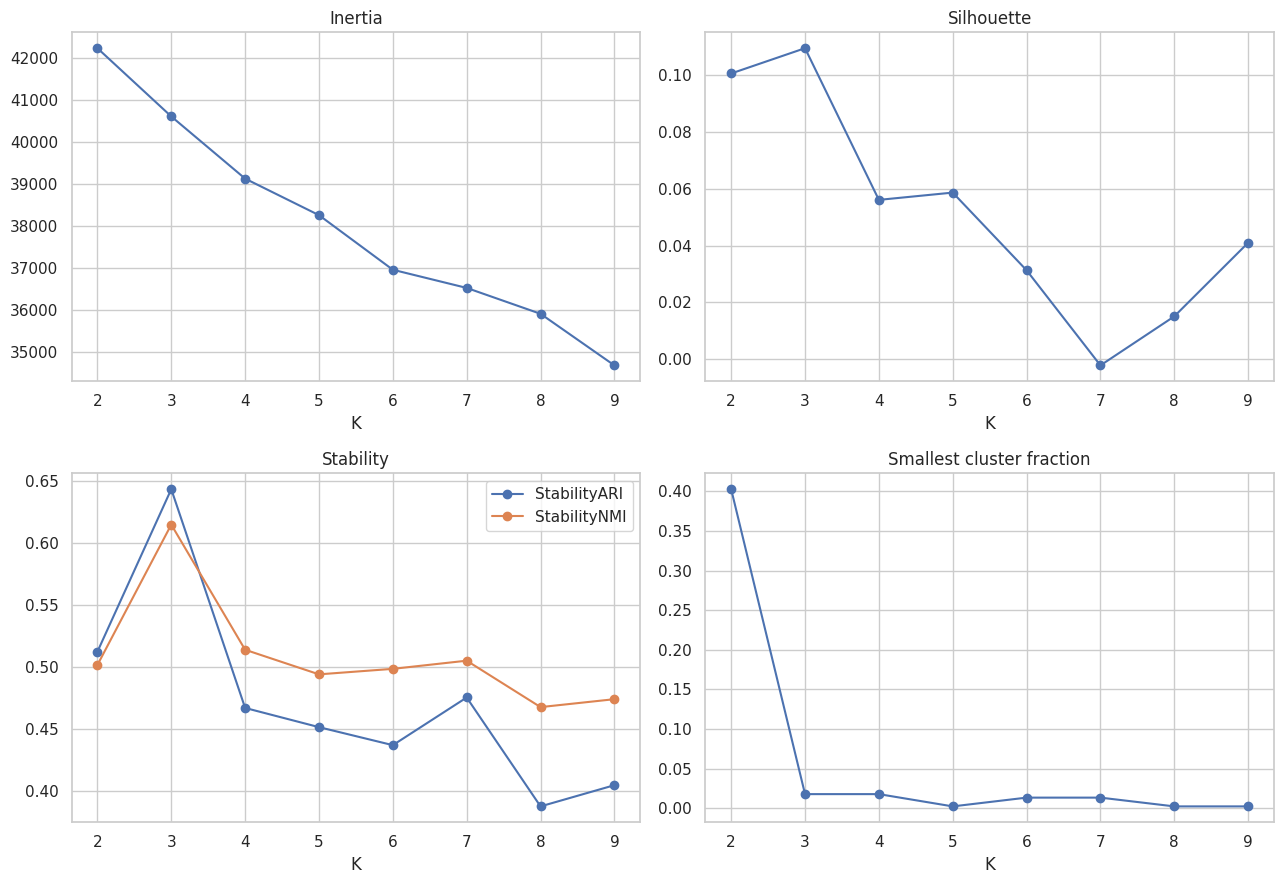

In [10]:
rng = np.random.default_rng(RANDOM_STATE)
k_rows = []
for k in K_VALUES:
    reference = KMeans(n_clusters=k, n_init=50, random_state=RANDOM_STATE)
    reference_labels = reference.fit_predict(X_discovery_pca)
    row = {'K': k, **clustering_metrics(X_discovery_pca, reference_labels)}
    stability_runs = []
    sample_n = max(k * 5, int(len(X_discovery_pca) * STABILITY_SAMPLE_FRACTION))
    for repeat in range(STABILITY_REPEATS):
        sample_idx = rng.choice(len(X_discovery_pca), size=sample_n, replace=True)
        model = KMeans(n_clusters=k, n_init=30, random_state=RANDOM_STATE + repeat + 1)
        model.fit(X_discovery_pca[sample_idx])
        stability_runs.append(model.predict(X_discovery_pca))
    row['StabilityARI'], row['StabilityNMI'] = mean_pairwise_agreement(stability_runs)
    row['Inertia'] = reference.inertia_
    k_rows.append(row)
k_results = pd.DataFrame(k_rows).set_index('K')
display(k_results)

eligible_k = k_results[(k_results['MinClusterFraction'] >= 0.03) & (k_results['StabilityARI'] >= 0.80)]
selection_passed_gates = not eligible_k.empty
if eligible_k.empty:
    print('No K met the stability and balance gates; selecting an exploratory fallback only.')
    ranked = k_results.assign(combined_rank=k_results['StabilityARI'].rank(ascending=False) + k_results['Silhouette'].rank(ascending=False))
    selected_k = int(ranked['combined_rank'].idxmin())
else:
    selected_k = int(eligible_k['Silhouette'].idxmax())
selected_solution_status = 'accepted' if selection_passed_gates else 'exploratory_fallback'
print('Selected K:', selected_k)
print('Selected solution status:', selected_solution_status)
if not selection_passed_gates:
    print('Do not describe or operationalise this solution as a validated learner taxonomy.')
interpret_diagnostics = k_results.loc[INTERPRET_K_VALUES]
display(interpret_diagnostics)
for interpret_k, row in interpret_diagnostics.iterrows():
    accepted = row['Silhouette'] >= 0.10 and row['StabilityARI'] >= 0.80 and row['MinClusterFraction'] >= 0.03
    print(f"K={interpret_k}: {'ACCEPTED FOR FURTHER VALIDATION' if accepted else 'REJECTED AS PRIMARY SOLUTION'}")

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
k_results['Inertia'].plot(marker='o', ax=axes[0, 0], title='Inertia')
k_results['Silhouette'].plot(marker='o', ax=axes[0, 1], title='Silhouette')
k_results[['StabilityARI', 'StabilityNMI']].plot(marker='o', ax=axes[1, 0], title='Stability')
k_results['MinClusterFraction'].plot(marker='o', ax=axes[1, 1], title='Smallest cluster fraction')
plt.tight_layout(); plt.show()

## Selected K-Means model and held-out learner assignment

In [11]:
kmeans = KMeans(n_clusters=selected_k, n_init=50, random_state=RANDOM_STATE)
discovery_labels = kmeans.fit_predict(X_discovery_pca)
validation_labels = kmeans.predict(X_validation_pca)
cluster_labels = pd.Series(index=profiles.index, dtype='float64', name='cluster')
cluster_labels.loc[discovery_users] = discovery_labels
cluster_labels.loc[validation_users] = validation_labels
cluster_labels = cluster_labels.astype(int)
print('Discovery metrics'); display(pd.Series(clustering_metrics(X_discovery_pca, discovery_labels)))
print('Validation metrics'); display(pd.Series(clustering_metrics(X_validation_pca, validation_labels)))
display(cluster_labels.value_counts().sort_index().rename('learners'))

Discovery metrics


,0
Silhouette,0.109580
DBI,2.550429
CHI,29.515207
Clusters,3.000000
NoiseFraction,0.000000
MinClusterFraction,0.017699


Validation metrics


,0
Silhouette,0.110247
DBI,2.164293
CHI,12.443490
Clusters,3.000000
NoiseFraction,0.000000
MinClusterFraction,0.017699


,learners
cluster,
0,10
1,222
2,333


## Repeated algorithm comparison and DBSCAN tuning

In [12]:
compare_rng = np.random.default_rng(RANDOM_STATE)
compare_n = max(selected_k * 5, int(len(X_discovery_pca) * ALGORITHM_SAMPLE_FRACTION))
compare_n = min(compare_n, len(X_discovery_pca) - 1)
if compare_n < selected_k * 5:
    raise ValueError('Too few discovery learners for a meaningful repeated algorithm comparison.')
assert compare_n < len(X_discovery_pca), 'Repeated comparison must use genuine subsamples.'
print(f'Algorithm comparison uses {compare_n}/{len(X_discovery_pca)} discovery learners per repeat.')
comparison_rows, comparison_samples = [], []
for repeat in range(ALGORITHM_REPEATS):
    idx = compare_rng.choice(len(X_discovery_pca), size=compare_n, replace=False)
    X_compare = X_discovery_pca[idx]
    comparison_samples.append(X_compare)
    labels_by_model = {
        'KMeans': KMeans(n_clusters=selected_k, n_init=30, random_state=RANDOM_STATE + repeat).fit_predict(X_compare),
        'Hierarchical': AgglomerativeClustering(n_clusters=selected_k, linkage='ward').fit_predict(X_compare),
        'GMM-diagonal': GaussianMixture(n_components=selected_k, covariance_type='diag', reg_covar=1e-5, random_state=RANDOM_STATE + repeat).fit_predict(X_compare),
    }
    for name, labels in labels_by_model.items():
        comparison_rows.append({'Repeat': repeat, 'Model': name, **clustering_metrics(X_compare, labels)})
algorithm_results = pd.DataFrame(comparison_rows)
algorithm_summary = algorithm_results.groupby('Model').agg(
    SilhouetteMean=('Silhouette', 'mean'), SilhouetteStd=('Silhouette', 'std'),
    DBIMean=('DBI', 'mean'), CHIMean=('CHI', 'mean'),
    MinClusterFractionMean=('MinClusterFraction', 'mean'),
    MinClusterFractionMinimum=('MinClusterFraction', 'min'),
).sort_values('SilhouetteMean', ascending=False)
display(algorithm_results); display(algorithm_summary)

X_compare = comparison_samples[0]
dbscan_candidates = []
for min_samples in [5, 10, 20]:
    n_neighbors = min(min_samples, len(X_compare) - 1)
    distances, _ = NearestNeighbors(n_neighbors=n_neighbors).fit(X_compare).kneighbors(X_compare)
    for quantile in [0.60, 0.70, 0.80, 0.90, 0.95]:
        eps = float(np.quantile(distances[:, -1], quantile))
        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_compare)
        dbscan_candidates.append({'eps': eps, 'min_samples': min_samples, 'labels': labels, **clustering_metrics(X_compare, labels, ignore_noise=True)})
dbscan_grid = pd.DataFrame([{k: v for k, v in row.items() if k != 'labels'} for row in dbscan_candidates]).sort_values(['Silhouette', 'NoiseFraction'], ascending=[False, True])
display(dbscan_grid)
valid_dbscan = [row for row in dbscan_candidates if np.isfinite(row['Silhouette']) and row['Clusters'] >= 2 and row['NoiseFraction'] <= 0.50]
best_dbscan = max(valid_dbscan, key=lambda row: row['Silhouette']) if valid_dbscan else None
print('Usable DBSCAN found:', best_dbscan is not None)

Algorithm comparison uses 361/452 discovery learners per repeat.


,Repeat,Model,Silhouette,DBI,CHI,Clusters,NoiseFraction,MinClusterFraction
0,0,KMeans,0.182800,2.223371,23.175580,3,0.0,0.008310
1,0,Hierarchical,0.058290,2.497529,20.187906,3,0.0,0.008310
2,0,GMM-diagonal,0.024116,7.591463,5.365660,3,0.0,0.130194
3,1,KMeans,0.058732,3.156496,24.705387,3,0.0,0.096953
4,1,Hierarchical,0.197994,2.295806,21.859010,3,0.0,0.011080
5,1,GMM-diagonal,0.244949,3.872012,9.636181,3,0.0,0.002770
6,2,KMeans,0.146687,2.337953,24.773403,3,0.0,0.016620
7,2,Hierarchical,0.110789,2.518932,23.065239,3,0.0,0.013850
8,2,GMM-diagonal,-0.033375,7.107978,4.909087,3,0.0,0.163435
9,3,KMeans,0.106735,2.322809,25.148624,3,0.0,0.011080


,SilhouetteMean,SilhouetteStd,DBIMean,CHIMean,MinClusterFractionMean,MinClusterFractionMinimum
Model,,,,,,
Hierarchical,0.105553,0.062649,2.835374,21.247213,0.055679,0.00831
KMeans,0.101368,0.047059,2.725992,24.414788,0.053463,0.00831
GMM-diagonal,0.085228,0.108371,6.370890,6.297469,0.090582,0.00277


,eps,min_samples,Silhouette,DBI,CHI,Clusters,NoiseFraction,MinClusterFraction
14,20.322680,20,NaN,NaN,NaN,1,0.033241,NaN
4,19.315320,5,NaN,NaN,NaN,1,0.038781,NaN
9,19.622080,10,NaN,NaN,NaN,1,0.038781,NaN
13,15.912690,20,NaN,NaN,NaN,1,0.074792,NaN
8,15.708274,10,NaN,NaN,NaN,1,0.077562,NaN
3,14.996119,5,NaN,NaN,NaN,1,0.085873,NaN
12,11.003205,20,NaN,NaN,NaN,1,0.144044,NaN
7,10.514932,10,NaN,NaN,NaN,1,0.157895,NaN
2,10.072608,5,NaN,NaN,NaN,1,0.174515,NaN
11,9.529408,20,NaN,NaN,NaN,1,0.202216,NaN


Usable DBSCAN found: False


## PCA and exposure ablations

In [13]:
non_pca_labels = KMeans(n_clusters=selected_k, n_init=50, random_state=RANDOM_STATE).fit_predict(X_discovery_scaled)
pca_comparison = pd.DataFrame([
    {'Space': 'PCA', **clustering_metrics(X_discovery_pca, discovery_labels)},
    {'Space': 'Full scaled', **clustering_metrics(X_discovery_scaled, non_pca_labels)},
])
display(pca_comparison)

ablation_rows, ablation_labels = [], {}
for name, columns in feature_sets.items():
    local = SimpleImputer(strategy='median').fit_transform(profiles.loc[discovery_users, columns])
    local = StandardScaler().fit_transform(local)
    if local.shape[1] > 1:
        local = PCA(n_components=PCA_VARIANCE, random_state=RANDOM_STATE).fit_transform(local)
    labels = KMeans(n_clusters=selected_k, n_init=50, random_state=RANDOM_STATE).fit_predict(local)
    ablation_labels[name] = labels
    ablation_rows.append({'FeatureSet': name, 'InputFeatures': len(columns), 'OutputDimensions': local.shape[1], **clustering_metrics(local, labels)})
ablation_results = pd.DataFrame(ablation_rows).set_index('FeatureSet')
ablation_agreement = pd.DataFrame([
    {'FeatureSet': name, 'ARIWithExposureOnly': adjusted_rand_score(labels, ablation_labels['exposure_only'])}
    for name, labels in ablation_labels.items() if name != 'exposure_only'
])
display(ablation_results); display(ablation_agreement)

,Space,Silhouette,DBI,CHI,Clusters,NoiseFraction,MinClusterFraction
0,PCA,0.109580,2.550429,29.515207,3,0.0,0.017699
1,Full scaled,0.100983,2.637773,27.886654,3,0.0,0.017699


,InputFeatures,OutputDimensions,Silhouette,DBI,CHI,Clusters,NoiseFraction,MinClusterFraction
FeatureSet,,,,,,,,
behaviour_mastery,111,69,0.109580,2.550429,29.515207,3,0.0,0.017699
combined_with_exposure,116,71,0.067922,3.156906,28.795115,3,0.0,0.099558
exposure_only,5,2,0.429820,0.855867,535.266014,3,0.0,0.283186


,FeatureSet,ARIWithExposureOnly
0,behaviour_mastery,0.021966
1,combined_with_exposure,0.057206


## Selected, five-cluster and six-cluster profiles

In [14]:
profile_view_cols = exposure_cols + behaviour_cols
selected_profiles = profiles[profile_view_cols].join(cluster_labels)
selected_profile_means = selected_profiles.groupby('cluster').mean()
selected_profile_means.insert(0, 'learners', cluster_labels.value_counts().sort_index())
display(selected_profile_means)
for interpret_k in INTERPRET_K_VALUES:
    model = KMeans(n_clusters=interpret_k, n_init=50, random_state=RANDOM_STATE).fit(X_discovery_pca)
    labels_all = pd.Series(index=profiles.index, dtype='float64', name='cluster')
    labels_all.loc[discovery_users] = model.labels_
    labels_all.loc[validation_users] = model.predict(X_validation_pca)
    labels_all = labels_all.astype(int)
    table = profiles[profile_view_cols].join(labels_all).groupby('cluster').mean()
    table.insert(0, 'learners', labels_all.value_counts().sort_index())
    print(f'Profiles for K={interpret_k}'); display(table)

,learners,log_interactions,log_active_days,interactions_per_active_day,observed_supported_skills,mean_mastery_confidence,success_rate,problem_coverage_rate,step_coverage_rate,hierarchy_coverage_rate,skill_coverage_rate,avg_duration_log,median_duration_log,duration_log_iqr,avg_hints,avg_incorrects,avg_correct_actions,avg_problem_view
cluster,,,,,,,,,,,,,,,,,,
0,10,7.503053,3.192628,82.863547,72.400000,0.495285,0.841222,0.062998,0.298550,0.016309,0.044013,2.435120,2.245923,1.327474,0.167648,0.308986,1.154798,1.255355
1,222,6.404062,2.579565,59.775368,37.117117,0.260725,0.690323,0.067531,0.444094,0.021344,0.078728,2.854353,2.682619,1.561775,0.478119,0.724714,1.200027,1.879714
2,333,6.015850,2.134139,67.157614,33.231231,0.223477,0.820340,0.091488,0.429451,0.032767,0.088066,2.704962,2.530509,1.318188,0.155704,0.385736,1.124957,1.431802


Profiles for K=5


,learners,log_interactions,log_active_days,interactions_per_active_day,observed_supported_skills,mean_mastery_confidence,success_rate,problem_coverage_rate,step_coverage_rate,hierarchy_coverage_rate,skill_coverage_rate,avg_duration_log,median_duration_log,duration_log_iqr,avg_hints,avg_incorrects,avg_correct_actions,avg_problem_view
cluster,,,,,,,,,,,,,,,,,,
0,57,6.773790,2.973343,56.382025,41.754386,0.309814,0.615993,0.057429,0.512035,0.019018,0.070430,2.872370,2.714297,1.617804,0.731675,0.801365,1.297934,2.577032
1,1,7.277939,3.850148,31.456522,66.000000,0.430017,0.711818,0.060815,0.203179,0.008984,0.045612,2.844537,2.708050,1.665008,0.152039,0.805114,1.187975,1.469247
2,271,6.037538,2.242602,61.692846,32.926199,0.222623,0.739286,0.076825,0.434069,0.025431,0.094990,2.813434,2.635705,1.485094,0.321646,0.625381,1.149349,1.581344
3,231,6.208486,2.246771,69.725558,36.012987,0.244654,0.841570,0.093509,0.415449,0.033502,0.074353,2.670906,2.498697,1.280388,0.130129,0.324876,1.125724,1.401064
4,5,7.258661,3.035605,78.331097,68.400000,0.463265,0.852841,0.066630,0.318172,0.017797,0.053148,2.556085,2.352432,1.367089,0.116993,0.283826,1.175682,1.218022


Profiles for K=6


,learners,log_interactions,log_active_days,interactions_per_active_day,observed_supported_skills,mean_mastery_confidence,success_rate,problem_coverage_rate,step_coverage_rate,hierarchy_coverage_rate,skill_coverage_rate,avg_duration_log,median_duration_log,duration_log_iqr,avg_hints,avg_incorrects,avg_correct_actions,avg_problem_view
cluster,,,,,,,,,,,,,,,,,,
0,7,7.483379,3.128148,88.155639,72.571429,0.502073,0.846373,0.064926,0.310997,0.017193,0.046079,2.409403,2.214261,1.280525,0.144431,0.300392,1.172023,1.267070
1,211,6.180774,2.368098,60.880538,33.791469,0.231373,0.711660,0.070893,0.417123,0.022349,0.086757,2.842389,2.662095,1.541672,0.400548,0.702660,1.178307,1.670118
2,34,7.033777,3.156301,55.842884,43.500000,0.326913,0.596085,0.052299,0.498073,0.015719,0.047450,2.893867,2.761612,1.585621,0.826058,0.778988,1.277043,2.923479
3,170,5.708572,1.897988,66.441587,29.582353,0.191248,0.822157,0.100844,0.544257,0.039334,0.103377,2.698452,2.525959,1.285688,0.153085,0.383572,1.135782,1.515186
4,9,7.696335,3.431417,86.377965,73.000000,0.517165,0.758217,0.060184,0.345875,0.015469,0.036755,2.455409,2.254436,1.400891,0.344758,0.627689,1.176032,1.481736
5,134,6.452318,2.483862,67.374925,39.007463,0.273401,0.835034,0.083666,0.312094,0.026987,0.067890,2.708455,2.536272,1.340320,0.126332,0.333736,1.109336,1.306420


## Temporal external validation with effect sizes

In [15]:
early_outcomes = early.groupby('Anon Student Id').agg(early_success_rate=('Correct First Attempt', 'mean'))
later_outcomes = later.groupby('Anon Student Id').agg(
    future_success_rate=('Correct First Attempt', 'mean'),
    future_avg_hints=('Hints', 'mean'), future_avg_incorrects=('Incorrects', 'mean'),
    future_avg_duration_log=('duration_log', 'mean'), future_interactions=('Correct First Attempt', 'size'),
    future_first_time=('event_time', 'min'), future_last_time=('event_time', 'max'),
)
later_outcomes['future_active_span_days'] = (later_outcomes['future_last_time'] - later_outcomes['future_first_time']).dt.total_seconds() / 86400
later_outcomes['learning_gain'] = later_outcomes['future_success_rate'] - early_outcomes['early_success_rate']
validation_frame = later_outcomes.join(cluster_labels, how='inner')
outcome_cols = ['future_success_rate', 'future_avg_hints', 'future_avg_incorrects', 'future_avg_duration_log', 'future_active_span_days', 'learning_gain']
display(validation_frame.groupby('cluster')[outcome_cols].agg(['mean', 'median', 'count']))

test_rows = []
for outcome in outcome_cols:
    groups = [group[outcome].dropna().to_numpy() for _, group in validation_frame.groupby('cluster') if group[outcome].notna().sum() >= 2]
    if len(groups) >= 2:
        h, p = kruskal(*groups)
        total_n = sum(len(group) for group in groups)
        effect = max(0.0, (h - len(groups) + 1) / (total_n - len(groups)))
    else:
        h, p, effect = np.nan, np.nan, np.nan
    test_rows.append({'Outcome': outcome, 'KruskalH': h, 'PValue': p, 'EpsilonSquared': effect})
temporal_tests = pd.DataFrame(test_rows)
finite = temporal_tests['PValue'].notna()
p_values = temporal_tests.loc[finite, 'PValue'].to_numpy()
order = np.argsort(p_values)
holm_sorted = np.maximum.accumulate((len(p_values) - np.arange(len(p_values))) * p_values[order])
holm = np.empty_like(p_values); holm[order] = np.clip(holm_sorted, 0, 1)
temporal_tests.loc[finite, 'HolmAdjustedPValue'] = holm
temporal_tests = temporal_tests.sort_values('PValue')
display(temporal_tests)

future_success_rate                 future_avg_hints                  \
                       mean    median count             mean    median count   
cluster                                                                        
0                  0.842550  0.841153    10          0.16573  0.157947    10   
1                  0.710900  0.729093   222          0.44215  0.351614   222   
2                  0.814421  0.818945   333          0.17102  0.140741   333   

        future_avg_incorrects                 future_avg_duration_log  \
                         mean    median count                    mean   
cluster                                                                 
0                    0.243985  0.236859    10                2.107795   
1                    0.609181  0.535185   222                2.780126   
2                    0.393256  0.336283   333                2.677157   

                        future_active_span_days                   \
           median count                    mean     median count   
cluster                                                            
0        2.101608    10               36.371145  26.003142    10   
1        2.752060   222               42.167917  27.497726   222   
2        2.688226   333               32.231387  20.839109   333   

        learning_gain                  
                 mean    median count  
cluster                                
0            0.001328  0.004917    10  
1            0.020577  0.023333   222  
2           -0.005918 -0.007445   333

,Outcome,KruskalH,PValue,EpsilonSquared,HolmAdjustedPValue
0,future_success_rate,154.023282,3.583185e-34,0.270504,2.149911e-33
1,future_avg_hints,129.241419,8.621492e-29,0.226408,4.310746e-28
2,future_avg_incorrects,91.258913,1.525383e-20,0.158824,6.101530e-20
3,future_avg_duration_log,21.434782,2.215625e-05,0.034581,6.646874e-05
5,learning_gain,15.085295,5.299927e-04,0.023283,1.059985e-03
4,future_active_span_days,12.608540,1.828480e-03,0.018876,1.828480e-03


## Future-success baselines and incremental cluster value

In [16]:
discovery_future = later_outcomes.loc[discovery_users, 'future_success_rate']
validation_future = later_outcomes.loc[validation_users, 'future_success_rate']
truth = validation_future.to_numpy()
cluster_future_means = pd.DataFrame({'cluster': discovery_labels, 'future_success_rate': discovery_future.to_numpy()}).groupby('cluster')['future_success_rate'].mean()
global_prediction = np.repeat(discovery_future.mean(), len(validation_users))
cluster_prediction = pd.Series(validation_labels).map(cluster_future_means).to_numpy()
early_train = early_outcomes.loc[discovery_users, ['early_success_rate']]
early_valid = early_outcomes.loc[validation_users, ['early_success_rate']]
calibration = LinearRegression().fit(early_train, discovery_future)

predictive_cols = behaviour_cols + exposure_cols
train_x = profiles.loc[discovery_users, predictive_cols].copy()
valid_x = profiles.loc[validation_users, predictive_cols].copy()
train_cluster_x, valid_cluster_x = train_x.copy(), valid_x.copy()
for cluster_id in range(selected_k):
    train_cluster_x[f'cluster_{cluster_id}'] = (discovery_labels == cluster_id).astype(int)
    valid_cluster_x[f'cluster_{cluster_id}'] = (validation_labels == cluster_id).astype(int)

def make_future_model():
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', HistGradientBoostingRegressor(max_iter=200, learning_rate=0.05, max_leaf_nodes=15, l2_regularization=1.0, random_state=RANDOM_STATE)),
    ])
behaviour_model = make_future_model().fit(train_x, discovery_future)
behaviour_cluster_model = make_future_model().fit(train_cluster_x, discovery_future)
behaviour_prediction = behaviour_model.predict(valid_x)
behaviour_cluster_prediction = behaviour_cluster_model.predict(valid_cluster_x)
predictions = {
    'Global mean': global_prediction, 'Cluster only': cluster_prediction,
    'Early success carried forward': early_valid['early_success_rate'].to_numpy(),
    'Calibrated early success': calibration.predict(early_valid),
    'Behaviour model': behaviour_prediction,
    'Behaviour model + cluster': behaviour_cluster_prediction,
}
prediction_results = pd.DataFrame([{'Model': name, 'MAE': mean_absolute_error(truth, pred)} for name, pred in predictions.items()]).sort_values('MAE')
display(prediction_results)
bootstrap_rng = np.random.default_rng(RANDOM_STATE)
improvements = []
for _ in range(2_000):
    idx = bootstrap_rng.integers(0, len(truth), size=len(truth))
    improvements.append(mean_absolute_error(truth[idx], behaviour_prediction[idx]) - mean_absolute_error(truth[idx], behaviour_cluster_prediction[idx]))
incremental_test = pd.DataFrame([{
    'MeanMAEImprovement': np.mean(improvements),
    'CI95Lower': np.quantile(improvements, 0.025),
    'CI95Upper': np.quantile(improvements, 0.975),
    'ReliablePositiveImprovement': np.quantile(improvements, 0.025) > 0,
}])
display(incremental_test)

,Model,MAE
3,Calibrated early success,0.056180
2,Early success carried forward,0.058719
1,Cluster only,0.064333
5,Behaviour model + cluster,0.064418
4,Behaviour model,0.064497
0,Global mean,0.070129


,MeanMAEImprovement,CI95Lower,CI95Upper,ReliablePositiveImprovement
0,0.000102,-0.001566,0.001737,False


## Optional supervised feature importance

In [17]:
if RUN_SUPERVISED_IMPORTANCE:
    supervised_features = behaviour_cols + exposure_cols + mastery_cols
    train_x = profiles.loc[discovery_users, supervised_features]
    valid_x = profiles.loc[validation_users, supervised_features]
    model = make_future_model().fit(train_x, discovery_future)
    print('Supervised validation MAE:', mean_absolute_error(validation_future, model.predict(valid_x)))
    importance = permutation_importance(model, valid_x, validation_future, scoring='neg_mean_absolute_error', n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
    feature_importance = pd.DataFrame({'Feature': supervised_features, 'ImportanceMean': importance.importances_mean, 'ImportanceStd': importance.importances_std}).sort_values('ImportanceMean', ascending=False)
    display(feature_importance.head(30))

Supervised validation MAE: 0.05993362622097739


,Feature,ImportanceMean,ImportanceStd
0,success_rate,0.011634,0.002933
8,avg_hints,0.004038,0.001197
9,avg_incorrects,0.002699,0.001392
91,mastery_delta__[SkillRule: Remove constant; {a...,0.002581,0.000781
4,skill_coverage_rate,0.001038,0.000717
1,problem_coverage_rate,0.000656,0.000425
5,avg_duration_log,0.000619,0.000379
11,avg_problem_view,0.000551,0.000423
99,"mastery_delta__[SkillRule: ax+b=c, negative; a...",0.000266,0.000211
6,median_duration_log,0.000209,0.000217


## Save and verify reusable outputs

In [18]:
artifact_bundle = {
    'imputer': imputer, 'scaler': scaler, 'pca': pca, 'kmeans': kmeans,
    'feature_columns': feature_cols, 'selected_k': selected_k,
    'selected_solution_status': selected_solution_status,
    'main_feature_set': MAIN_FEATURE_SET, 'skill_priors': skill_priors,
    'kept_skills': list(kept_skills), 'mastery_prior_strength': MASTERY_PRIOR_STRENGTH,
    'random_state': RANDOM_STATE,
}
joblib.dump(artifact_bundle, OUTPUT_DIR / 'kdd_clustering_bundle.joblib')
assignments = profiles[profile_view_cols].join(cluster_labels)
assignments.to_csv(OUTPUT_DIR / 'learner_cluster_assignments.csv')
k_results.to_csv(OUTPUT_DIR / 'k_selection_results.csv')
algorithm_results.to_csv(OUTPUT_DIR / 'algorithm_comparison_repeats.csv', index=False)
algorithm_summary.to_csv(OUTPUT_DIR / 'algorithm_comparison_summary.csv')
dbscan_grid.to_csv(OUTPUT_DIR / 'dbscan_grid.csv', index=False)
pca_comparison.to_csv(OUTPUT_DIR / 'pca_comparison.csv', index=False)
ablation_results.to_csv(OUTPUT_DIR / 'feature_ablation_results.csv')
ablation_agreement.to_csv(OUTPUT_DIR / 'feature_ablation_agreement.csv', index=False)
selected_profile_means.to_csv(OUTPUT_DIR / 'selected_cluster_profiles.csv')
temporal_tests.to_csv(OUTPUT_DIR / 'temporal_validation_tests.csv', index=False)
prediction_results.to_csv(OUTPUT_DIR / 'future_success_prediction_baselines.csv', index=False)
incremental_test.to_csv(OUTPUT_DIR / 'incremental_cluster_test.csv', index=False)
if RUN_SUPERVISED_IMPORTANCE:
    feature_importance.to_csv(OUTPUT_DIR / 'future_success_feature_importance.csv', index=False)
dataset_summary = pd.DataFrame([{
    'Dataset': 'KDD', 'RawRows': cleaned_interaction_count,
    'EligibleLearners': len(profiles), 'EarlyRows': len(early), 'FutureRows': len(later),
    'RetainedSkills': len(kept_skills), 'InputFeatures': len(feature_cols),
    'PCAComponents': X_discovery_pca.shape[1], 'SelectedK': selected_k,
}])
dataset_summary.to_csv(OUTPUT_DIR / 'dataset_summary.csv', index=False)
run_config = {
    'data_path': DATA_PATH, 'row_limit': ROW_LIMIT, 'minimum_interactions': MIN_INTERACTIONS,
    'early_fraction': EARLY_FRACTION, 'minimum_skill_learners': MIN_SKILL_LEARNERS,
    'pca_variance': PCA_VARIANCE, 'algorithm_repeats': ALGORITHM_REPEATS,
    'selected_k': selected_k, 'selected_solution_status': selected_solution_status,
    'selection_passed_gates': bool(selection_passed_gates),
    'main_feature_set': MAIN_FEATURE_SET,
    'algorithm_sample_fraction': ALGORITHM_SAMPLE_FRACTION,
}
with open(OUTPUT_DIR / 'run_config.json', 'w') as file:
    json.dump(run_config, file, indent=2)

reloaded = joblib.load(OUTPUT_DIR / 'kdd_clustering_bundle.joblib')
assert reloaded['feature_columns'] == feature_cols and reloaded['selected_k'] == selected_k
assert len(reloaded['kmeans'].predict(X_validation_pca[:10])) == min(10, len(X_validation_pca))
assert len(pd.read_csv(OUTPUT_DIR / 'learner_cluster_assignments.csv')) == len(profiles)
print('Saved and verified:', OUTPUT_DIR)
print('\n'.join(f'{path.name}: {path.stat().st_size:,} bytes' for path in sorted(OUTPUT_DIR.iterdir()) if path.is_file()))

Saved and verified: /content/drive/MyDrive/datasets/kdd_final_outputs
algorithm_comparison_repeats.csv: 2,952 bytes
algorithm_comparison_summary.csv: 483 bytes
dataset_summary.csv: 148 bytes
dbscan_grid.csv: 779 bytes
feature_ablation_agreement.csv: 113 bytes
feature_ablation_results.csv: 424 bytes
future_success_feature_importance.csv: 11,333 bytes
future_success_prediction_baselines.csv: 253 bytes
incremental_cluster_test.csv: 139 bytes
k_selection_results.csv: 1,239 bytes
kdd_clustering_bundle.joblib: 109,016 bytes
learner_cluster_assignments.csv: 174,923 bytes
pca_comparison.csv: 250 bytes
run_config.json: 426 bytes
selected_cluster_profiles.csv: 1,324 bytes
temporal_validation_tests.csv: 677 bytes
